## Simulating Rabi oscillations with noise and decoherence

An example of solving using qiskit_dynamics the time evolution of a qubit being driven close to resonance. The model that we solve consists of a single qubit perturbed by a sinusoidal drive. In addition, will consider energy relaxation and decoherence terms modeled by using a Lindblad master equation.

### 1. Setting up the solver with the Hamiltonian model

In [40]:
import numpy as np
from qiskit.quantum_info import Operator
from qiskit_dynamics import Solver, Signal
   #Solver is the main object used to solve the time-evolution of a quantum system described by a time-dependent Hamiltonian,Signal is used to represent the time-dependent components of the Hamiltonia
#------------------------------------------
#Defining parameters
nu_z = 10 #Natural frequency (or Larmor frequency) of the qubit in Hertz (Hz). This is the energy splitting between the qubit states
nu_x = 1  #amplitude of a drive field applied along the X-axis
nu_d = .98  #frequency of the drive field,almost on resonance with the Hamiltonian's energy levels difference(Hz)

X = Operator.from_label('X')
Y = Operator.from_label('Y')
Z = Operator.from_label('Z')
s_p = 0.7 * (X + 1j * Y)
    #The raising operator s_p (also denoted as σ) is used to make transition a qubit from the ground state (∣0⟩) to the excited state (∣1⟩)

solver = Solver(
    static_hamiltonian=.5 * 2 * np.pi * nu_z * Z,
    hamiltonian_operators=[1/2 * np.pi * nu_x * X],
)

### 1.1 Solving the system
Define the initial state for the simulation, the time span to simulate for and the intermediate times for which the solution is requested,then solving the evolution.

In [41]:
from qiskit.quantum_info.states import Statevector
from qiskit.quantum_info import DensityMatrix

t_final = .5 / nu_x
tau = .5

y0 = Statevector([1., 0.]) #initial state

n_steps = int(np.ceil(t_final / tau)) + 1
t_eval = np.linspace(0., t_final, n_steps)
signals = [Signal(envelope=1., carrier_freq=nu_d)]

sol = solver.solve(t_span=[0., t_final], y0=y0, signals=signals, t_eval=t_eval)
#The solver.solve() method is the main function that performs the time-evolution of a quantum system. It takes the Hamiltonian you defined earlier and integrates the Schrödinger equation to find out how the state of the qubit changes over time

In [42]:
from qiskit.quantum_info.states import Statevector
from qiskit.quantum_info import DensityMatrix

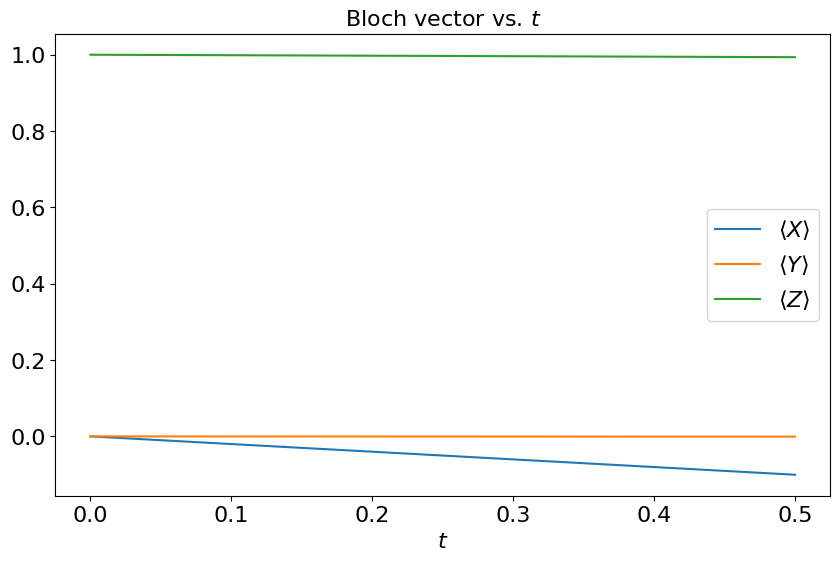

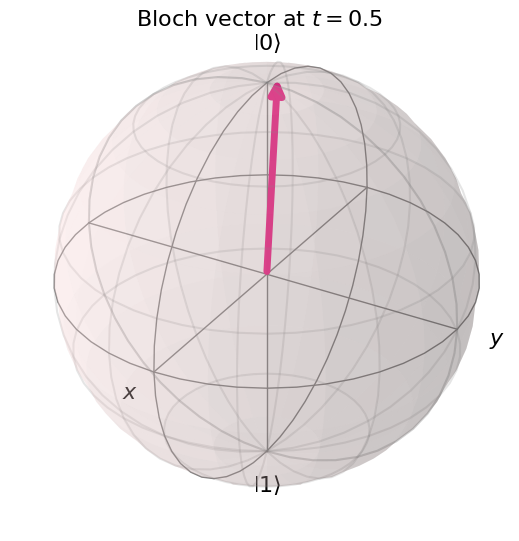

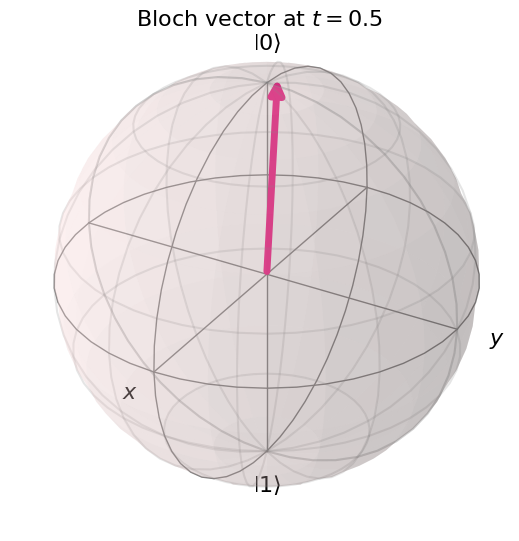

In [43]:
from qiskit.visualization import plot_bloch_vector
import matplotlib.pyplot as plt
%matplotlib inline

fontsize = 16

def plot_qubit_dynamics(sol, t_eval, X, Y, Z):
    n_times = len(sol.y)
    x_data = np.zeros((n_times,))
    y_data = np.zeros((n_times,))
    z_data = np.zeros((n_times,))

    for t_i, sol_t in enumerate(sol.y):
        x_data[t_i] = sol_t.expectation_value(X).real
        y_data[t_i] = sol_t.expectation_value(Y).real
        z_data[t_i] = sol_t.expectation_value(Z).real

    _, ax = plt.subplots(figsize = (10, 6))
    plt.rcParams.update({'font.size': fontsize})
    plt.plot(t_eval, x_data, label = '$\\langle X \\rangle$')
    plt.plot(t_eval, y_data, label = '$\\langle Y \\rangle$')
    plt.plot(t_eval, z_data, label = '$\\langle Z \\rangle$')
    plt.legend(fontsize = fontsize)
    ax.set_xlabel('$t$', fontsize = fontsize)
    ax.set_title('Bloch vector vs. $t$', fontsize = fontsize)
    plt.show()

    display(plot_bloch_vector([x_data[-1], y_data[-1], z_data[-1]],
                              f'Bloch vector at $t = {t_eval[-1]}$'))

plot_qubit_dynamics(sol, t_eval, X, Y, Z)